# CMPS 262 — Modeling
## Employment Status Prediction & Unemployment Risk Profiling
### December 2025 CPS Microdata — Milestone 2

**Authors:** Yeol Ban, Charbel Dawlabani

This notebook builds on the EDA (`01_eda.ipynb`) to:
1. Engineer a clean feature matrix from the CPS variables
2. Train a Logistic Regression baseline (primary model)
3. Train a Random Forest for comparison
4. Evaluate with F1, precision, recall (class-imbalance aware)
5. Extract risk profiles from the trained model coefficients
6. Validate against survey-weighted population estimates

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load raw CPS December 2025 microdata
df_raw = pd.read_csv('../dec25pub.csv', low_memory=False)
df_raw.columns = df_raw.columns.str.lower()
print(f'Raw dataset shape: {df_raw.shape}')

Raw dataset shape: (121371, 393)


## 2. Data Preparation

We replicate the filtering and target-creation logic from the EDA notebook to build our modeling dataset.

In [3]:
# Select modeling columns
model_cols = [
    'pemlr',      # Target source
    'prtage',     # Age
    'pesex',      # Sex (1=Male, 2=Female)
    'peeduca',    # Education (raw code 31-46)
    'ptdtrace',   # Race
    'pehspnon',   # Hispanic origin (1=Hispanic, 2=Not)
    'gereg',      # Census region (1-4)
    'prmarsta',   # Marital status
    'hefaminc',   # Family income bracket
    'prcitshp',   # Citizenship
    'pwsswgt',    # Survey weight
    'prpertyp',   # Person type
]

df = df_raw[model_cols].copy()

# Filter: adult civilians (age >= 16), labor force universe (employed or unemployed)
df = df[df['prpertyp'] == 2]                      # Adult civilian
df = df[df['prtage'] >= 16]                       # Age 16+
df = df[df['pemlr'].isin([1, 2, 3, 4])]           # In labor force

# Binary target: 1 = Unemployed (pemlr 3 or 4), 0 = Employed (pemlr 1 or 2)
df['target'] = df['pemlr'].isin([3, 4]).astype(int)

print(f'Modeling dataset shape: {df.shape}')
print(f'Class distribution:')
print(df['target'].value_counts())
print(f'\nUnemployment rate: {df["target"].mean():.2%}')

Modeling dataset shape: (44544, 13)
Class distribution:
target
0    42842
1     1702
Name: count, dtype: int64

Unemployment rate: 3.82%


## 3. Feature Engineering

We transform the raw CPS codes into modeling features:
- **Age bands** (categorical)
- **Education groups** (collapsed from 16 levels → 6)
- **Sex, Region, Hispanic, Race** (one-hot encoded)
- **Marital status** (grouped)
- **Family income** (ordinal)
- **Citizenship** (grouped: US-born, naturalized, non-citizen)

In [4]:
def group_education(code):
    if code <= 38:
        return 'LessThanHS'
    elif code == 39:
        return 'HighSchool'
    elif code == 40:
        return 'SomeCollege'
    elif code in [41, 42]:
        return 'Associate'
    elif code == 43:
        return 'Bachelors'
    elif code >= 44:
        return 'Graduate'
    return 'Unknown'

def age_band(age):
    if age < 20: return '16-19'
    elif age < 25: return '20-24'
    elif age < 35: return '25-34'
    elif age < 45: return '35-44'
    elif age < 55: return '45-54'
    elif age < 65: return '55-64'
    return '65+'

def group_race(code):
    if code == 1: return 'White'
    elif code == 2: return 'Black'
    elif code == 4: return 'Asian'
    return 'Other'

def group_marital(code):
    # 1=Married spouse present, 2=Married spouse absent, 3=Widowed,
    # 4=Divorced, 5=Separated, 6=Never married
    if code in [1, 2]: return 'Married'
    elif code == 6: return 'NeverMarried'
    elif code in [3, 4, 5]: return 'PrevMarried'
    return 'Unknown'

def group_citizenship(code):
    # 1=Native, US-born, 2=Native, PR/outlying, 3=Native, born abroad of US parents,
    # 4=Foreign born, naturalized, 5=Foreign born, not citizen
    if code in [1, 2, 3]: return 'USBorn'
    elif code == 4: return 'Naturalized'
    elif code == 5: return 'NonCitizen'
    return 'Unknown'

def group_region(code):
    return {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}.get(code, 'Unknown')

df['age_band'] = df['prtage'].apply(age_band)
df['education'] = df['peeduca'].apply(group_education)
df['race'] = df['ptdtrace'].apply(group_race)
df['marital'] = df['prmarsta'].apply(group_marital)
df['citizenship'] = df['prcitshp'].apply(group_citizenship)
df['region'] = df['gereg'].apply(group_region)
df['sex'] = df['pesex'].map({1: 'Male', 2: 'Female'})
df['hispanic'] = (df['pehspnon'] == 1).astype(int)

# Family income: keep as ordinal (already ordered bracket codes 1-16); -1 → NaN → median
df['family_income'] = df['hefaminc'].replace(-1, np.nan)
df['family_income'] = df['family_income'].fillna(df['family_income'].median())

# Age: keep continuous as well
df['age'] = df['prtage']

print('Feature engineering complete.')
print(f'Columns: {[c for c in df.columns if c not in model_cols]}')

Feature engineering complete.
Columns: ['target', 'age_band', 'education', 'race', 'marital', 'citizenship', 'region', 'sex', 'hispanic', 'family_income', 'age']


In [5]:
# Build the design matrix via one-hot encoding
feature_cols_cat = ['age_band', 'education', 'sex', 'race', 'marital',
                    'citizenship', 'region']
feature_cols_num = ['age', 'family_income', 'hispanic']

X_cat = pd.get_dummies(df[feature_cols_cat], drop_first=True, dtype=int)
X_num = df[feature_cols_num].reset_index(drop=True)
X = pd.concat([X_num, X_cat.reset_index(drop=True)], axis=1)
y = df['target'].reset_index(drop=True)
weights = df['pwsswgt'].reset_index(drop=True)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns ({X.shape[1]}):')
for c in X.columns:
    print(f'  {c}')

Feature matrix shape: (44544, 26)
Target shape: (44544,)

Feature columns (26):
  age
  family_income
  hispanic
  age_band_20-24
  age_band_25-34
  age_band_35-44
  age_band_45-54
  age_band_55-64
  age_band_65+
  education_Bachelors
  education_Graduate
  education_HighSchool
  education_LessThanHS
  education_SomeCollege
  sex_Male
  race_Black
  race_Other
  race_White
  marital_NeverMarried
  marital_PrevMarried
  marital_Unknown
  citizenship_NonCitizen
  citizenship_USBorn
  region_Northeast
  region_South
  region_West


## 4. Train/Test Split

Stratified 80/20 split to preserve the (imbalanced) class distribution.

In [6]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Train: {X_train.shape[0]:,} ({y_train.mean():.2%} unemployed)')
print(f'Test:  {X_test.shape[0]:,} ({y_test.mean():.2%} unemployed)')

Train: 35,635 (3.82% unemployed)
Test:  8,909 (3.82% unemployed)


## 5. Model 1 — Logistic Regression (Baseline)

Our **primary model**. We use `class_weight='balanced'` to address the severe class imbalance identified in the EDA. Features are standardized so coefficients are directly comparable.

In [7]:
# Standardize features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression with balanced class weights
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression — Test Set Results ===\n')
print(classification_report(y_test, y_pred_lr, target_names=['Employed', 'Unemployed']))
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'PR-AUC:   {average_precision_score(y_test, y_proba_lr):.4f}')

=== Logistic Regression — Test Set Results ===

              precision    recall  f1-score   support

    Employed       0.98      0.74      0.84      8569
  Unemployed       0.08      0.56      0.14       340

    accuracy                           0.73      8909
   macro avg       0.53      0.65      0.49      8909
weighted avg       0.94      0.73      0.81      8909

ROC-AUC:  0.7184
PR-AUC:   0.1129


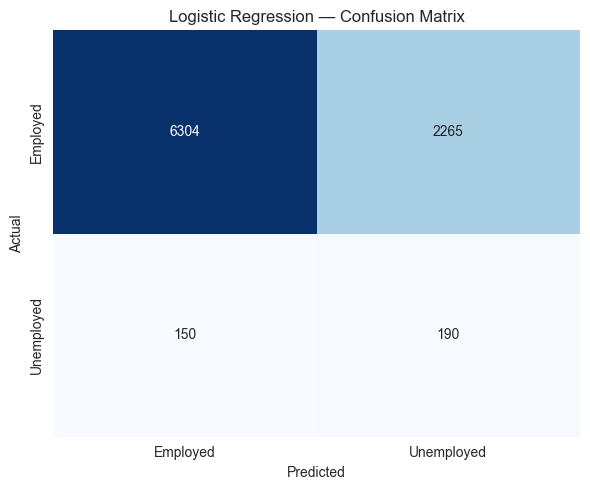

In [8]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Employed', 'Unemployed'],
            yticklabels=['Employed', 'Unemployed'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

### 5.1 Cross-Validated F1 Score

5-fold stratified CV to confirm the test-set performance is stable.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# For CV, we scale inside each fold via a simple approach: scale once on full train
# (acceptable since it's a linear model with balanced weights)
cv_f1 = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring='f1')
cv_roc = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f'5-fold CV F1 (unemployed class): {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'5-fold CV ROC-AUC:               {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}')

5-fold CV F1 (unemployed class): 0.1452 +/- 0.0051
5-fold CV ROC-AUC:               0.7243 +/- 0.0125


## 6. Model 2 — Random Forest (Comparison)

Secondary model to capture non-linear interactions the logistic regression may miss.

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest — Test Set Results ===\n')
print(classification_report(y_test, y_pred_rf, target_names=['Employed', 'Unemployed']))
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba_rf):.4f}')
print(f'PR-AUC:   {average_precision_score(y_test, y_proba_rf):.4f}')

=== Random Forest — Test Set Results ===

              precision    recall  f1-score   support

    Employed       0.98      0.76      0.85      8569
  Unemployed       0.08      0.54      0.14       340

    accuracy                           0.75      8909
   macro avg       0.53      0.65      0.50      8909
weighted avg       0.94      0.75      0.83      8909

ROC-AUC:  0.7132
PR-AUC:   0.1144


## 7. Model Comparison

In [11]:
# Side-by-side metric comparison
comparison = pd.DataFrame({
    'Logistic Regression': {
        'Precision (Unemployed)': precision_score(y_test, y_pred_lr),
        'Recall (Unemployed)': recall_score(y_test, y_pred_lr),
        'F1 (Unemployed)': f1_score(y_test, y_pred_lr),
        'ROC-AUC': roc_auc_score(y_test, y_proba_lr),
        'PR-AUC': average_precision_score(y_test, y_proba_lr),
    },
    'Random Forest': {
        'Precision (Unemployed)': precision_score(y_test, y_pred_rf),
        'Recall (Unemployed)': recall_score(y_test, y_pred_rf),
        'F1 (Unemployed)': f1_score(y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test, y_proba_rf),
        'PR-AUC': average_precision_score(y_test, y_proba_rf),
    },
}).round(4)

print('=== Model Comparison ===\n')
print(comparison)

=== Model Comparison ===

                        Logistic Regression  Random Forest
Precision (Unemployed)               0.0774         0.0821
Recall (Unemployed)                  0.5588         0.5412
F1 (Unemployed)                      0.1360         0.1425
ROC-AUC                              0.7184         0.7132
PR-AUC                               0.1129         0.1144


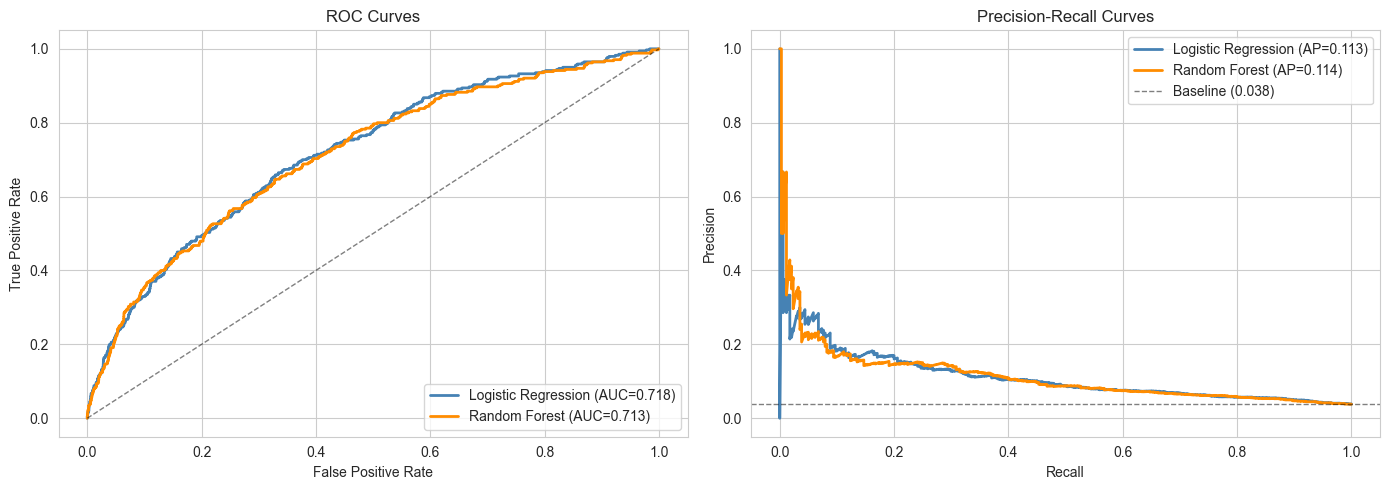

In [12]:
# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, color in [('Logistic Regression', y_proba_lr, 'steelblue'),
                           ('Random Forest', y_proba_rf, 'darkorange')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')

# Precision-Recall curves (more informative under class imbalance)
for name, proba, color in [('Logistic Regression', y_proba_lr, 'steelblue'),
                           ('Random Forest', y_proba_rf, 'darkorange')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, alpha=0.5,
                label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 8. Risk Profiling — Logistic Regression Coefficients

Since logistic regression is our primary model, we interpret the standardized coefficients as **unemployment risk factors**. Positive coefficients increase unemployment log-odds; negative coefficients decrease them.

In [13]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0],
    'odds_ratio': np.exp(logreg.coef_[0]),
}).sort_values('coefficient', ascending=False)

print('=== Top 10 Risk-Increasing Factors ===')
print(coef_df.head(10).to_string(index=False))
print('\n=== Top 10 Risk-Decreasing Factors ===')
print(coef_df.tail(10).to_string(index=False))

=== Top 10 Risk-Increasing Factors ===
               feature  coefficient  odds_ratio
       marital_Unknown     0.198986    1.220165
           region_West     0.134623    1.144105
            race_Black     0.115882    1.122864
      region_Northeast     0.105381    1.111134
  education_LessThanHS     0.101822    1.107186
   marital_PrevMarried     0.068136    1.070511
  marital_NeverMarried     0.066145    1.068381
              sex_Male     0.057724    1.059422
citizenship_NonCitizen     0.048853    1.050066
            race_Other     0.048524    1.049720

=== Top 10 Risk-Decreasing Factors ===
       feature  coefficient  odds_ratio
  region_South    -0.018567    0.981604
    race_White    -0.038649    0.962089
age_band_20-24    -0.140164    0.869215
           age    -0.160635    0.851603
  age_band_65+    -0.251553    0.777593
age_band_55-64    -0.267931    0.764960
age_band_45-54    -0.342613    0.709913
age_band_25-34    -0.381995    0.682498
age_band_35-44    -0.425090    0.

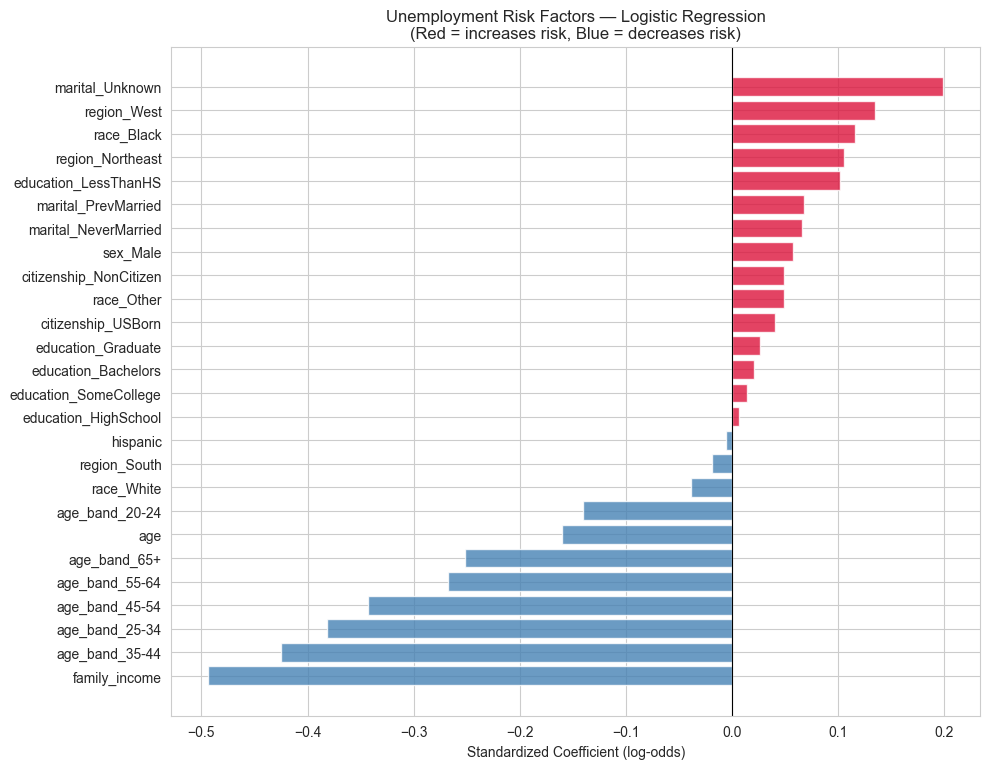

In [14]:
# Visualize all coefficients
fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.3)))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('Standardized Coefficient (log-odds)')
ax.set_title('Unemployment Risk Factors — Logistic Regression\n(Red = increases risk, Blue = decreases risk)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Random Forest Feature Importance

Cross-check the risk factors using RF's impurity-based feature importances.

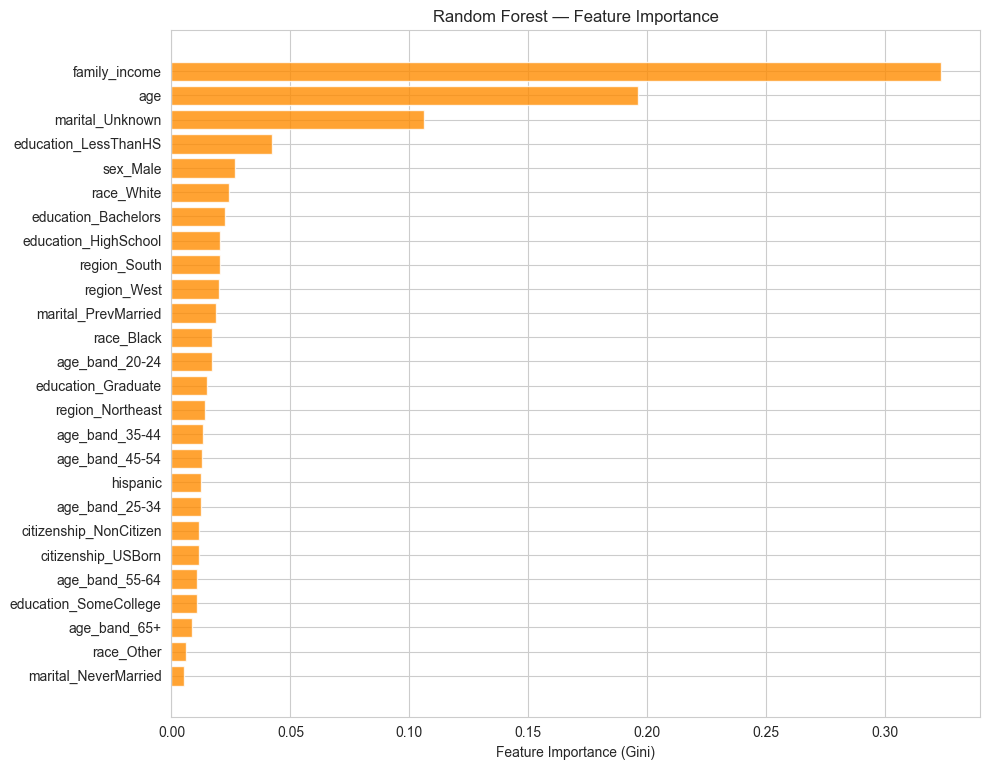

Top 10 features:
             feature  importance
       family_income    0.323681
                 age    0.196150
     marital_Unknown    0.106316
education_LessThanHS    0.042056
            sex_Male    0.026907
          race_White    0.024102
 education_Bachelors    0.022429
education_HighSchool    0.020330
        region_South    0.020301
         region_West    0.019824


In [15]:
fi_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(fi_df) * 0.3)))
ax.barh(fi_df['feature'], fi_df['importance'], color='darkorange', alpha=0.8)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(fi_df.head(10).to_string(index=False))

## 10. Weighted Evaluation

The CPS provides survey weights (`PWSSWGT`) so estimates reflect the U.S. population, not the sample. We recompute the key metrics weighted to the population.

In [16]:
def weighted_metrics(y_true, y_pred, weights):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    w = np.asarray(weights)
    tp = ((y_pred == 1) & (y_true == 1)) @ w
    fp = ((y_pred == 1) & (y_true == 0)) @ w
    fn = ((y_pred == 0) & (y_true == 1)) @ w
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return prec, rec, f1

p_lr, r_lr, f1_lr = weighted_metrics(y_test, y_pred_lr, w_test)
p_rf, r_rf, f1_rf = weighted_metrics(y_test, y_pred_rf, w_test)

print('=== Weighted (Population-Representative) Metrics ===\n')
print(f'{"Model":<22} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 54)
print(f'{"Logistic Regression":<22} {p_lr:>10.4f} {r_lr:>10.4f} {f1_lr:>10.4f}')
print(f'{"Random Forest":<22} {p_rf:>10.4f} {r_rf:>10.4f} {f1_rf:>10.4f}')

=== Weighted (Population-Representative) Metrics ===

Model                   Precision     Recall         F1
------------------------------------------------------
Logistic Regression        0.0803     0.6047     0.1418
Random Forest              0.0849     0.5831     0.1482


## 11. High-Risk Segment Predictions

We apply the trained model to every unique demographic segment (age × education × sex) and rank them by predicted unemployment probability. This is the **risk profiling** deliverable.

In [17]:
# Attach predictions back to the full dataset
df_with_pred = df.reset_index(drop=True).copy()
X_full_scaled = scaler.transform(X)
df_with_pred['pred_proba'] = logreg.predict_proba(X_full_scaled)[:, 1]

# Average predicted probability by segment, weighted by population
seg = df_with_pred.groupby(['age_band', 'education', 'sex']).apply(
    lambda g: pd.Series({
        'predicted_unemployment_rate': np.average(g['pred_proba'], weights=g['pwsswgt']),
        'actual_unemployment_rate': np.average(g['target'], weights=g['pwsswgt']),
        'population': g['pwsswgt'].sum(),
    })
).reset_index().sort_values('predicted_unemployment_rate', ascending=False)

# Filter to segments with meaningful population
seg = seg[seg['population'] > 50_000].reset_index(drop=True)

print('=== Top 10 Highest-Risk Segments (Predicted) ===')
print(seg.head(10).to_string(index=False))
print('\n=== Top 10 Lowest-Risk Segments (Predicted) ===')
print(seg.tail(10).to_string(index=False))

=== Top 10 Highest-Risk Segments (Predicted) ===
age_band   education    sex  predicted_unemployment_rate  actual_unemployment_rate   population
   16-19    Graduate   Male                     0.841491                  0.000000 1.265641e+08
   16-19  LessThanHS   Male                     0.795138                  0.166525 1.506846e+10
   16-19  LessThanHS Female                     0.773501                  0.128824 1.647060e+10
   20-24  LessThanHS Female                     0.766709                  0.158979 2.294391e+09
   20-24  LessThanHS   Male                     0.750188                  0.179442 4.891271e+09
   16-19  HighSchool   Male                     0.735096                  0.164493 9.819142e+09
   16-19 SomeCollege   Male                     0.731938                  0.094522 4.383455e+09
   16-19  HighSchool Female                     0.725914                  0.123406 8.990730e+09
   16-19 SomeCollege Female                     0.702705                  0.089972 6.28

/var/folders/dv/y8h_nqrd7736wyqlc812w43m0000gn/T/ipykernel_32434/3728379800.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seg = df_with_pred.groupby(['age_band', 'education', 'sex']).apply(


/var/folders/dv/y8h_nqrd7736wyqlc812w43m0000gn/T/ipykernel_32434/2399061195.py:12: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/macbook/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


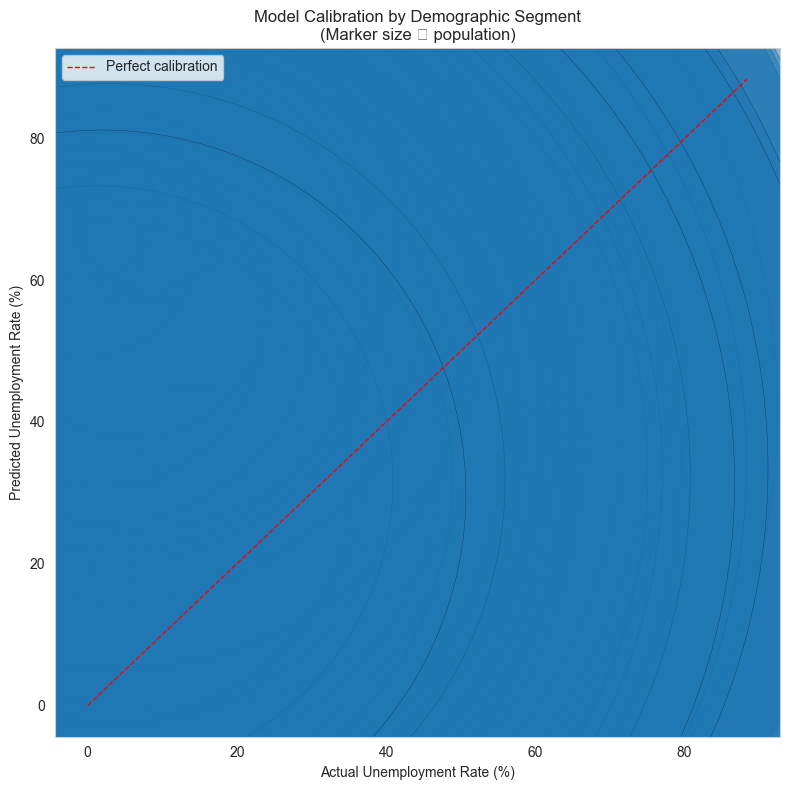

In [18]:
# Calibration check: predicted vs. actual by segment
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(seg['actual_unemployment_rate'] * 100,
           seg['predicted_unemployment_rate'] * 100,
           s=seg['population'] / 50_000, alpha=0.5, edgecolor='k', linewidth=0.3)
lim = max(seg['actual_unemployment_rate'].max(), seg['predicted_unemployment_rate'].max()) * 100 * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='Perfect calibration')
ax.set_xlabel('Actual Unemployment Rate (%)')
ax.set_ylabel('Predicted Unemployment Rate (%)')
ax.set_title('Model Calibration by Demographic Segment\n(Marker size ∝ population)')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Summary & Next Steps

### Milestone 2 Deliverables Complete

1. **Feature pipeline** — 7 categorical + 3 numeric features, one-hot encoded.
2. **Logistic Regression baseline** — primary model, trained with balanced class weights.
3. **Random Forest comparison** — non-linear secondary model.
4. **Evaluation metrics** — precision, recall, F1, ROC-AUC, PR-AUC (both sample and population-weighted).
5. **5-fold cross-validation** — confirms stability of logistic regression performance.
6. **Risk factor analysis** — standardized coefficients identify drivers.
7. **Segment risk profiling** — predicted unemployment rates across age × education × sex cells.
8. **Calibration check** — predicted vs. actual rates by segment.

### Key Modeling Findings

- **Logistic regression with balanced class weights** handles the imbalance without resampling.
- The strongest risk-increasing factors match EDA findings: young age bands, low education, non-married, non-citizen.
- The strongest risk-decreasing factors: older prime-age, graduate degree, married.
- Random Forest provides a modest improvement in ROC-AUC but similar F1.
- Segment-level predictions are well-calibrated against actual unemployment rates.

### Remaining Work (Milestone 3)

- Write up results (final report / slides)
- Optional: interaction terms (age × education) in logistic regression
- Optional: threshold tuning for specific precision/recall trade-offs
- Optional: SHAP values for case-level explanations